# Tutorial

This tutorial demonstrates how to use LineageVI for RNA velocity analysis with gene programs.

We will show how to:

1) Inspect and download the gene sets of interest from EnrichR
2) Annotate an AnnData with the gene set
3) Process the data
4) Initialize and train the model
5) Fetch the model outputs
6) Plot the phase planes
7) Visualize the velocity UMAP and pseudotime
8) Rank genes or gene programs across clusters
9) Run statistical tests 
10) Plot heatmaps
11) Run perturbation experiments
12) Estimate velocity uncertainty 

In [51]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [1]:
# Library loading
import lineagevi
import scanpy as sc
import scvelo as scv
import numpy as np
import os

In [15]:
adata = sc.read_h5ad('/home/lgolinelli/git/lineageVI/outputs/pancreas_20260222_184006/adata_preprocessed.h5ad')
adata

AnnData object with n_obs × n_vars = 3696 × 2116
    obs: 'clusters_coarse', 'clusters', 'S_score', 'G2M_score', 'initial_size_unspliced', 'initial_size_spliced', 'initial_size', 'n_counts', 'leiden'
    var: 'highly_variable_genes', 'gene_count_corr', 'means', 'dispersions', 'dispersions_norm', 'highly_variable'
    uns: 'clusters_coarse_colors', 'clusters_colors', 'day_colors', 'indices', 'leiden', 'log1p', 'neighbors', 'pca', 'terms'
    obsm: 'X_pca', 'X_umap'
    varm: 'PCs', 'mask'
    layers: 'Ms', 'Mu', 'counts', 'spliced', 'unspliced'
    obsp: 'connectivities', 'distances'

In [53]:
# Download pancreas dataset
adata = scv.datasets.pancreas()

In [54]:
# Obtain raw counts for the annotation step
adata.X = adata.layers['unspliced'].copy() + adata.layers['spliced'].copy()
adata.layers['counts'] = adata.X.copy()

In [ ]:
# Explore available libraries
libs = lineagevi.utils.list_enrichr_libraries()
libs[["libraryName", "numTerms"]][:]

,libraryName,numTerms
0,Genome_Browser_PWMs,615
1,TRANSFAC_and_JASPAR_PWMs,326
2,Transcription_Factor_PPIs,290
3,ChEA_2013,353
4,Drug_Perturbations_from_GEO_2014,701
...,...,...
220,JASPAR_PWM_Human_2025,675
221,JASPAR_PWM_Mouse_2025,146
222,Sciplex_Drug_Perturbation_Signatures_2025,4604
223,Carcinogenome,11748


In [12]:
# Download several into a directory
lineagevi.utils.download_enrichr_libraries(
    ["GO_Biological_Process_2025", "GO_Molecular_Function_2025", "KEGG_2026"],
    output_dir="/home/lgolinelli/git/lineageVI/gene_sets",
)

['/home/lgolinelli/git/lineageVI/gene_sets/GO_Biological_Process_2025.gmt',
 '/home/lgolinelli/git/lineageVI/gene_sets/GO_Molecular_Function_2025.gmt',
 '/home/lgolinelli/git/lineageVI/gene_sets/KEGG_2026.gmt']

# Maybe try doing filter and normalize and moments before annotation
# OR REDUCE KL OR INCREASE CAPACITY

In [ ]:
scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=3000, subset_highly_variable=True, log=True)
scv.pp.moments(adata, n_pcs=100, n_neighbors=200) # Smoothing over 200 neighbors helps to denoise the biological trajectories for RNA velocity analysis.
sc.tl.leiden(adata) # Using clusters helps the model to learn multi-lineage dynamics.

Filtered out 20801 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 3000 highly variable genes.
Logarithmized X.


/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/preprocessing/utils.py:705: DeprecationWarning: `log1p` is deprecated since scVelo v0.3.0 and will be removed in a future version. Please use `log1p` from `scanpy.pp` instead.
  log1p(adata)
/tmp/ipykernel_2217542/2324577645.py:2: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=100, n_neighbors=200) # Smoothing over 200 neighbors helps to denoise the biological trajectories for RNA velocity analysis.
/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(
/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/

computing neighbors
    finished (0:00:00) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:01) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [ ]:
# Create the binary matrix of gene sets, filtering out any gene program with less than 12 genes for interpretability.
bio_process_path = '/home/lgolinelli/git/lineageVI/gene_sets/GO_Biological_Process_2025.gmt'
min_genes=12
lineagevi.utils.add_annotations(
    adata, 
    files=[bio_process_path],
    min_genes=min_genes,
    varm_key='mask',
    uns_key='terms',
    clean=False,
    genes_use_upper=True)

# Remove genes not present in any retained terms.
adata._inplace_subset_var(adata.varm['mask'].sum(1) > 0)

In [ ]:
# Standard scVelo preprocessing
#scv.pp.filter_and_normalize(adata, min_shared_counts=20, n_top_genes=3000, subset_highly_variable=True, log=True)
#scv.pp.moments(adata, n_pcs=100, n_neighbors=200) # Smoothing over 200 neighbors helps to denoise the biological trajectories for RNA velocity analysis.
#sc.tl.leiden(adata) # Using clusters helps the model to learn multi-lineage dynamics.

In [60]:
# We remove terms that contain less than 12 genes after filtering out HVGs.
select_terms = adata.varm['mask'].sum(0)>min_genes
adata.uns['terms'] = np.array(adata.uns['terms'])[select_terms].tolist()
adata.varm['mask'] = adata.varm['mask'][:, select_terms]

# Again, we remove genes not present in any retained terms.
adata._inplace_subset_var(adata.varm['mask'].sum(1)>0) 

In [61]:
# We check the final number of genes and gene programs
adata.varm['mask'].shape

(1483, 106)

In [62]:
# We store the matrix of neighbors indices in the AnnData object; required for training. 
lineagevi.utils.get_neighbor_indices(adata, K=20, neighbors_key='neighbors', indices_key='indices')  # Gets 20 neighbors + self = 21 total

Train/val split: 3326 train, 370 val (train_size=0.9)
[Regime1] Epoch 1/400 - train loss: 20.5360 (recon: 20.5360, kl: 1070.2779) - val loss: 18.3335 (recon: 18.3335, kl: 3291.4739)
[Regime1] Epoch 2/400 - train loss: 25.8988 (recon: 19.1410, kl: 1067.7442) - val loss: 20.0201 (recon: 19.5749, kl: 70.3411)
[Regime1] Epoch 3/400 - train loss: 20.2818 (recon: 19.4737, kl: 63.8436) - val loss: 19.3849 (recon: 18.4066, kl: 77.2874)
[Regime1] Epoch 4/400 - train loss: 19.6754 (recon: 18.5070, kl: 61.5347) - val loss: 18.8800 (recon: 17.5438, kl: 70.3718)
[Regime1] Epoch 5/400 - train loss: 19.2130 (recon: 17.6877, kl: 60.2512) - val loss: 18.5002 (recon: 17.0181, kl: 58.5449)
[Regime1] Epoch 6/400 - train loss: 18.8106 (recon: 17.2273, kl: 50.0315) - val loss: 18.1586 (recon: 16.4210, kl: 54.9070)
[Regime1] Epoch 7/400 - train loss: 18.5067 (recon: 16.7338, kl: 46.6865) - val loss: 17.9264 (recon: 16.1409, kl: 47.0187)
[Regime1] Epoch 8/400 - train loss: 18.2076 (recon: 16.3724, kl: 41.4229

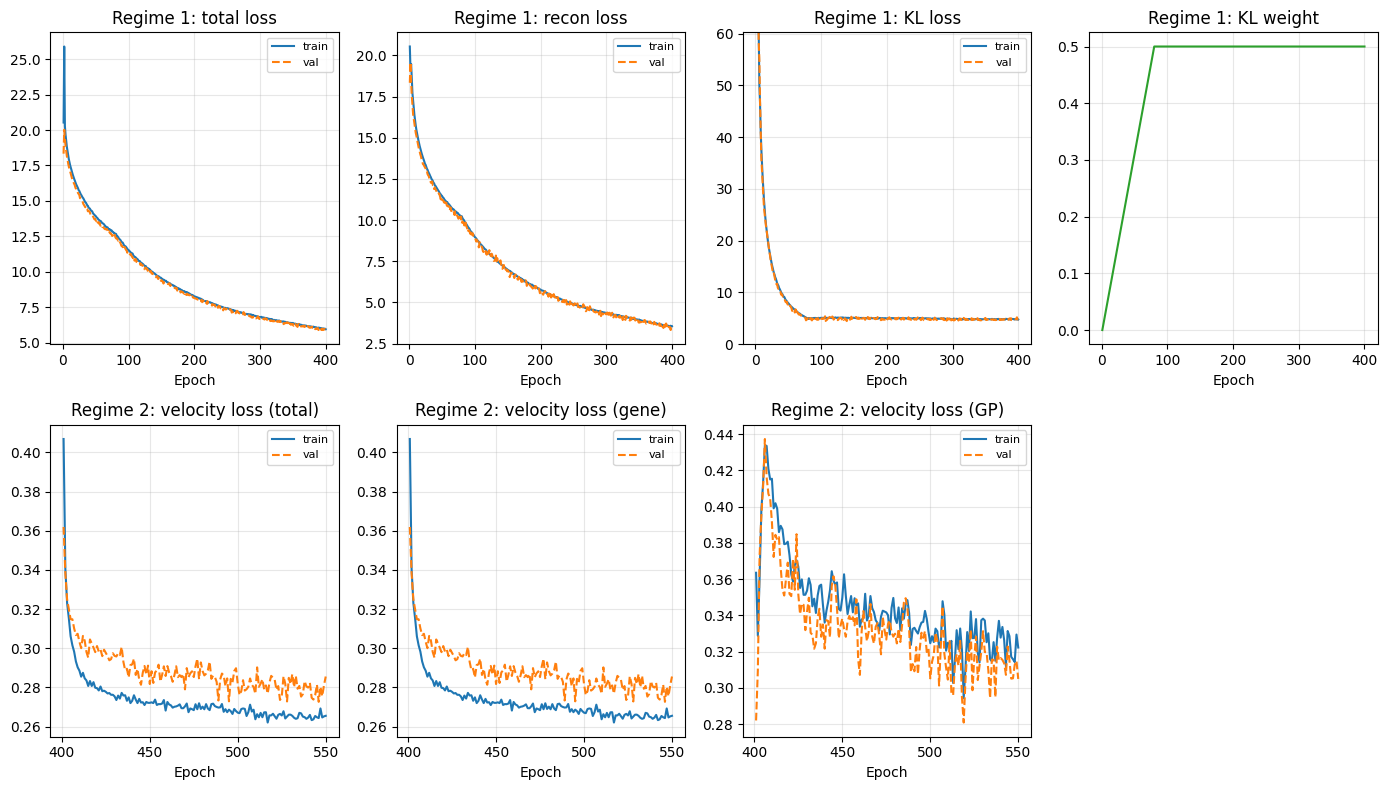

Saved loss curves → /home/lgolinelli/git/lineageVI/notebooks/data/outputs/pancreas/training_plots/loss_curves.png
Saved model  → /home/lgolinelli/git/lineageVI/notebooks/data/outputs/pancreas/pretrained_vae.pt
Saved config → /home/lgolinelli/git/lineageVI/notebooks/data/outputs/pancreas/model_config.json
Note: Call model.get_model_outputs() to annotate adata with velocities


In [ ]:
# Model initialization
vae = lineagevi.LineageVI(
    adata=adata,
    n_hidden=128,
    n_layers = 1,
    dropout = 0,
    mask_key='I',
    unspliced_key='Mu', # make sure to use smoothed spliced and unspliced expression values: 'Mu' and 'Ms'
    spliced_key='Ms',
    nn_key='indices',
    cluster_key='leiden',  # Key in adata.obs
    cluster_embedding_dim=32,  # Optional, default is 32
)

# Model fitting
history = vae.fit(
    K=10,
    batch_size=256,
    lr_regime1=1e-2,
    lr_regime2=5e-3,
    train_size=0.9,
    velocity_loss_weight_gene = 1.0,
    velocity_loss_weight_gp = 0,
    epochs1=400, #initially 400
    epochs2=150, #initially 100
    seeds=(0, 1, 2),
    output_dir='/home/lgolinelli/git/lineageVI/notebooks/data/outputs/pancreas',   # or None
    verbose=1,
    monitor_genes=['Gnas', 'Rbfox3'],
    monitor_negative_velo=True,
    monitor_every_epochs=25,
    #kl_weight = 0.1,
    kl_weight_schedule='linear',
    kl_weight_min=0.0,
    kl_weight_max=.5,
    kl_cycle_ramp_frac=0.2,
)

In [64]:
# Store model outputs in the anndata
vae.get_model_outputs(
    adata=adata,
    return_negative_velo=False,
    base_seed=0,
    save_to_adata=True,
    unspliced_key='Mu',
    spliced_key='Ms',
    nn_key='indices',
    rescale_velocity_magnitude=False, # the more turbulent the velocity flow, the smaller the velocity magnitude
    max_velocity_magnitude=1,
)

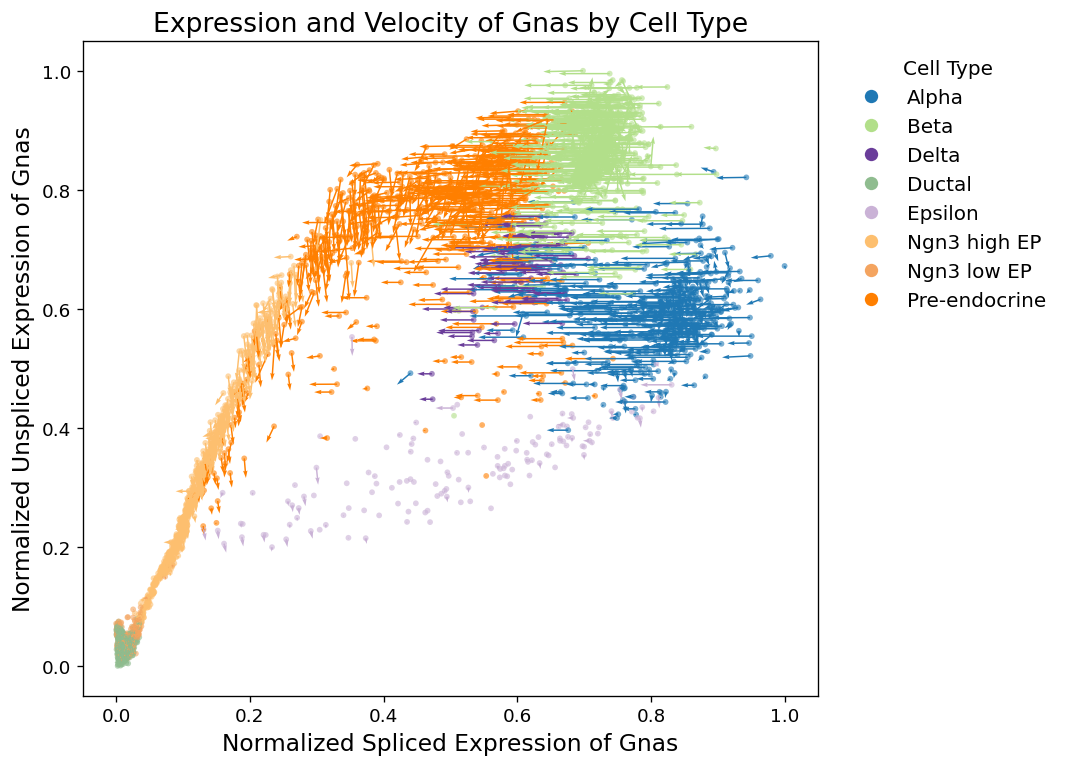

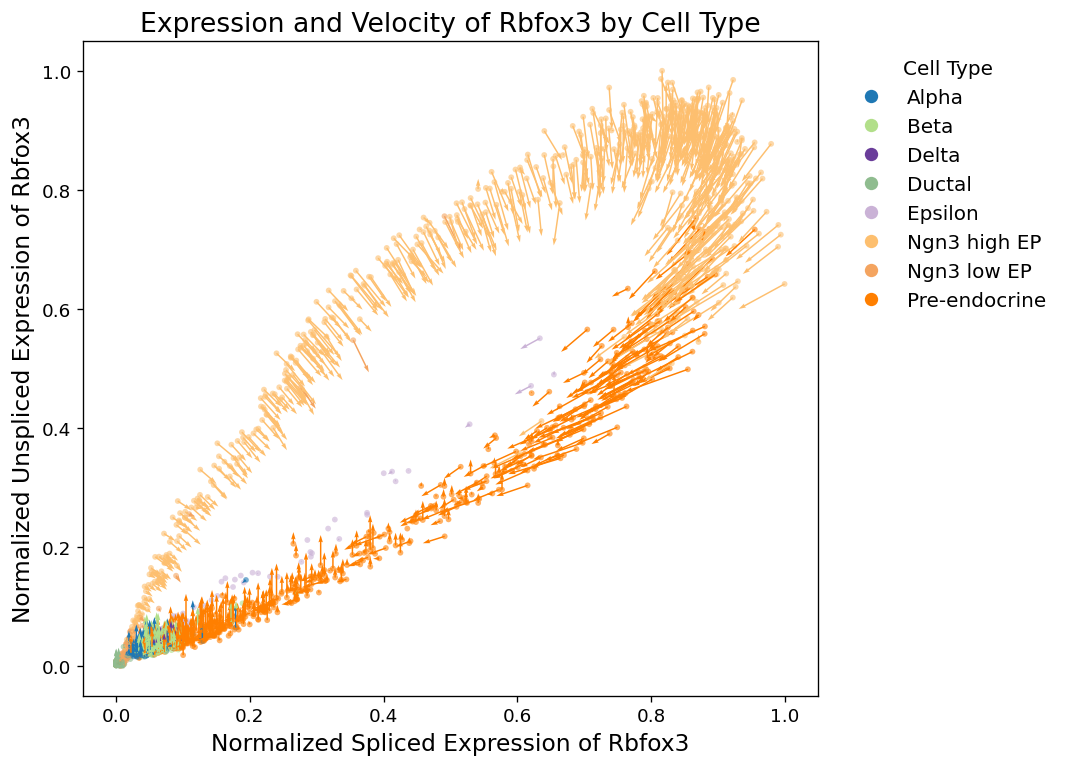

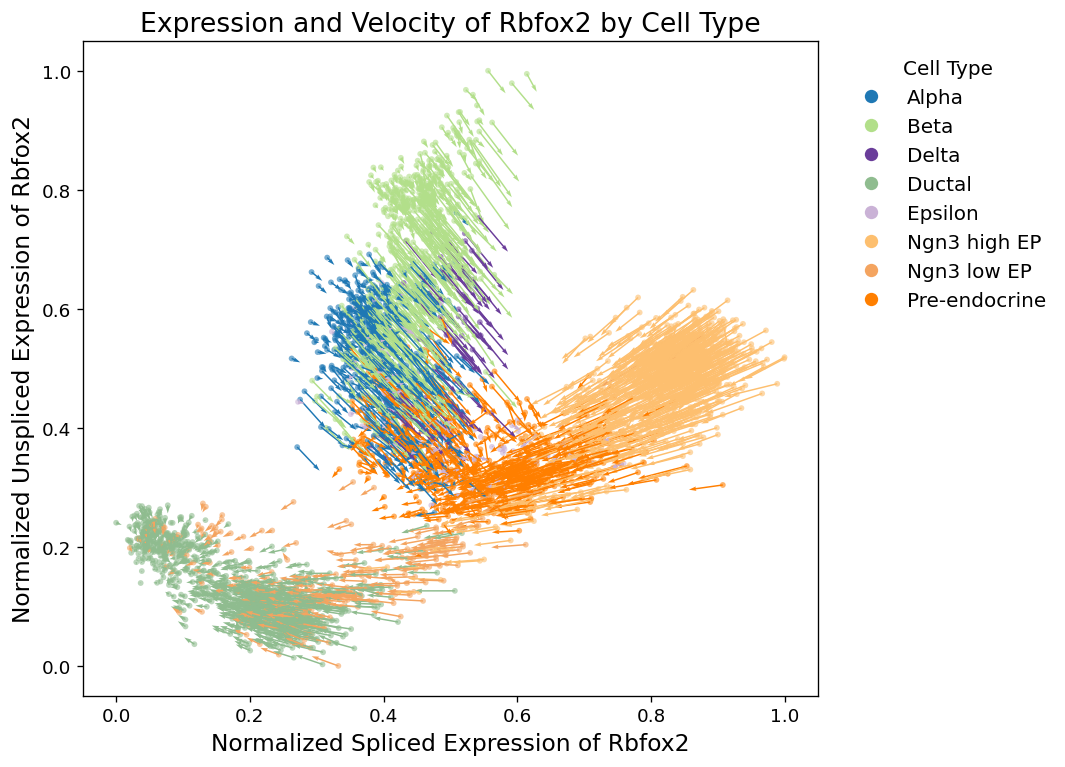

(<Figure size 1080x780 with 1 Axes>,
 <Axes: title={'center': 'Expression and Velocity of Rbfox2 by Cell Type'}, xlabel='Normalized Spliced Expression of Rbfox2', ylabel='Normalized Unspliced Expression of Rbfox2'>)

In [65]:
# Visualization of phase planes at the gene level
lineagevi.plots.plot_phase_plane(adata,  'Gnas', cluster_key='clusters', u_scale=.1, s_scale=.1, alpha=1, head_width=0.02, head_length=0.03, length_includes_head=False)
lineagevi.plots.plot_phase_plane(adata,  'Rbfox3', cluster_key='clusters', u_scale=.1, s_scale=.1, alpha=1, head_width=0.02, head_length=0.03, length_includes_head=False)
lineagevi.plots.plot_phase_plane(adata,  'Rbfox2', cluster_key='clusters', u_scale=.1, s_scale=.1, alpha=1, head_width=0.02, head_length=0.03, length_includes_head=False)

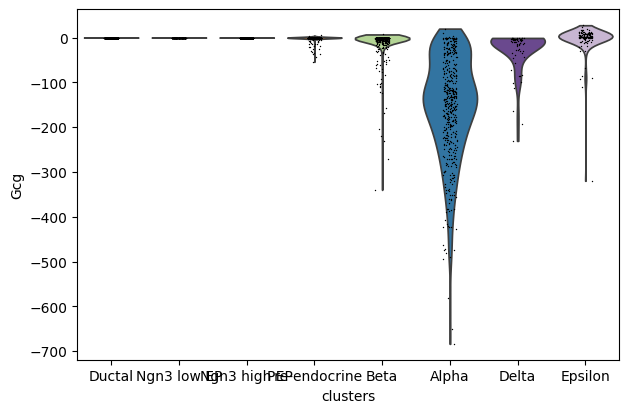

In [66]:
# Violin plot of velocity for the Gcg gene
sc.pl.violin(adata, keys='Gcg', layer='velocity', groupby='clusters')

computing velocity graph (using 1/64 cores)


  0%|          | 0/3696 [00:00<?, ?cells/s]

    finished (0:00:02) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/lgolinelli/miniconda3/envs/l

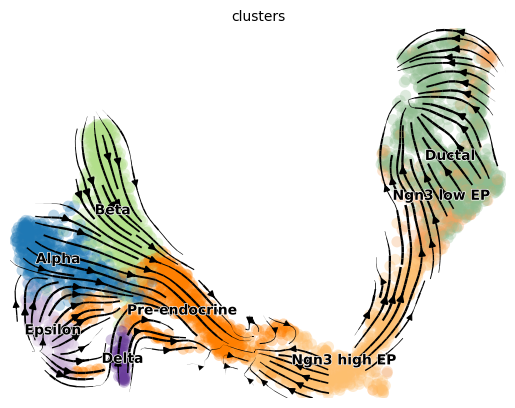

computing terminal states
    identified 3 regions of root cells and 2 regions of end points .
    finished (0:00:00) --> added
    'root_cells', root cells of Markov diffusion process (adata.obs)
    'end_points', end points of Markov diffusion process (adata.obs)


/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/lgolinelli/miniconda3/envs/l

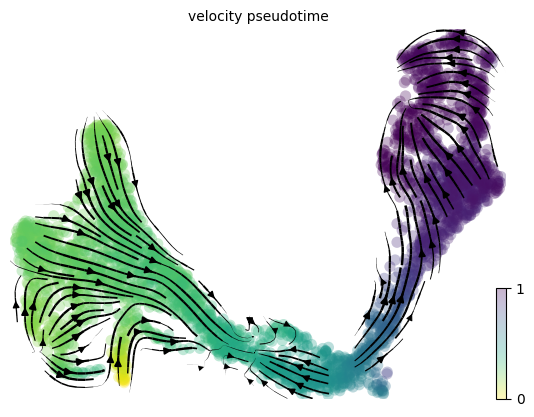

In [67]:
# We compute the velocity UMAP
cluster_key='clusters'
sc.pp.neighbors(adata)
sc.tl.umap(adata)
scv.tl.velocity_graph(adata)
scv.pl.velocity_embedding_stream(adata, color=cluster_key)
scv.tl.velocity_pseudotime(adata)
scv.pl.velocity_embedding_stream(adata, color='velocity_pseudotime')

In [68]:
# We rank the genes by their velocity in Beta cells
lineagevi.plots.top_features_table(adata, groupby_key="clusters", categories=['Beta', 'Ductal'], layer="velocity", n=10)

,feature,mean_activation,Beta mean,Ductal mean
1,Iapp,-52.361626,-133.429733,-0.056829
2,Pyy,-46.399681,-118.076790,-0.153885
3,Ttr,-6.284866,-11.890027,-2.668437
4,Sst,-5.678132,-14.470599,-0.005272
5,Gcg,-3.421759,-8.687977,-0.024016
6,Gnas,-2.124709,-5.335672,-0.053006
7,Calr,-2.033607,-5.094094,-0.058989
8,Ghrl,-1.910716,-4.417479,-0.293361
9,Sec61b,-1.742098,-4.637523,0.126017
10,Rps2,1.574204,1.222216,1.801301


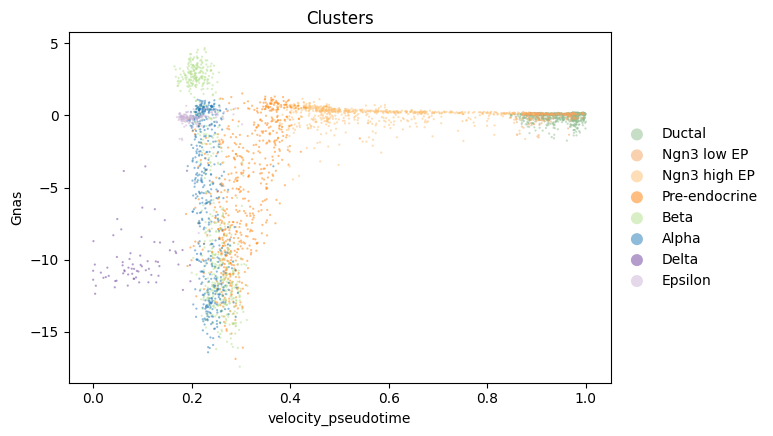

In [69]:
sc.pl.scatter(adata, x='velocity_pseudotime', y='Gnas', color='clusters', layers='velocity', size=10, alpha=0.5, title='Clusters')

computing velocity graph (using 1/64 cores)


  0%|          | 0/3696 [00:00<?, ?cells/s]

    finished (0:00:00) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])
/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


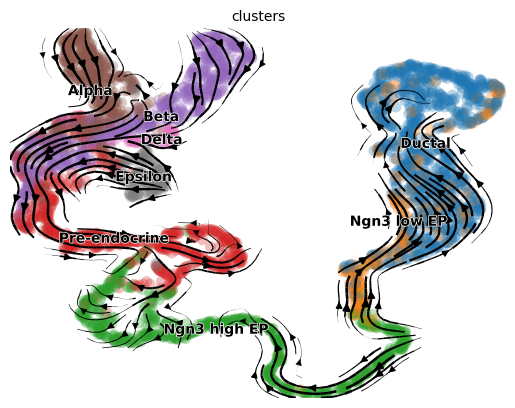

/home/lgolinelli/miniconda3/envs/lineagevi/lib/python3.11/site-packages/scvelo/plotting/utils.py:68: DeprecationWarning: is_categorical_dtype is deprecated and will be removed in a future version. Use isinstance(dtype, pd.CategoricalDtype) instead
  return isinstance(c, str) and c in data.obs.keys() and cat(data.obs[c])


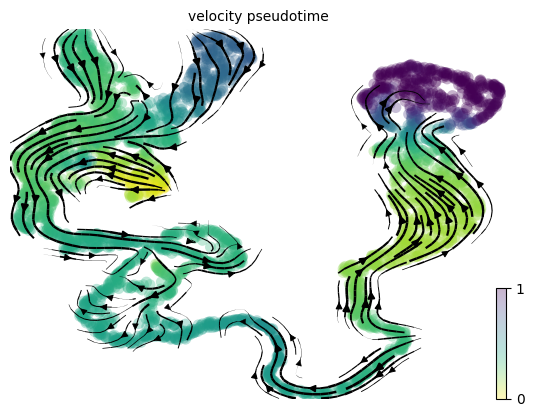

In [70]:
# We build the gene program anndata and compute the gene program velocity UMAP in the latent space
adata_gp = lineagevi.utils.build_gp_adata(adata)
sc.pp.neighbors(adata_gp)
sc.tl.umap(adata_gp)
scv.tl.velocity_graph(adata_gp)
scv.pl.velocity_embedding_stream(adata_gp, color=cluster_key)
scv.tl.velocity_pseudotime(adata_gp)
scv.pl.velocity_embedding_stream(adata_gp, color='velocity_pseudotime')

In [71]:
# We rank the gene programs by their GP velocity in Beta cells
lineagevi.plots.top_features_table(adata_gp, groupby_key="clusters", categories=['Alpha'], layer="velocity", n=10)

,feature,mean_activation,Alpha mean
1,G Protein-Coupled Receptor Binding (GO:0001664),7203.376465,7203.376465
2,Hormone Activity (GO:0005179),-4663.102051,-4663.102051
3,Receptor Ligand Activity (GO:0048018),1123.601074,1123.601074
4,Protein Kinase Activator Activity (GO:0030295),1089.647095,1089.647095
5,Protein Kinase Binding (GO:0019901),-81.506020,-81.506020
6,GTPase Activity (GO:0003924),-50.144524,-50.144524
7,Kinase Binding (GO:0019900),-46.261440,-46.261440
8,Ribonucleoside Triphosphate Phosphatase Activi...,37.683434,37.683434
9,Protein Homodimerization Activity (GO:0042803),10.536882,10.536882
10,Protein Kinase Regulator Activity (GO:0019887),-8.707673,-8.707673


In [72]:
# We plot pairs of gene programs, showing the gene program velocity in the space of latent state
lineagevi.plots.plot_gp_phase_planes(
    adata_gp,
    program_pairs=[('Regulation of Insulin Secretion (GO:0050796)', 'Negative Regulation of Cell Motility (GO:2000146)')],
    cluster_key='clusters',
    title='Phase Planes',
    figsize_per_panel = (7, 7),
    alpha = 1,
    arrow_multiplier=.01
)

KeyError: "Program 'Regulation of Insulin Secretion (GO:0050796)' not in adata_gp.var_names."

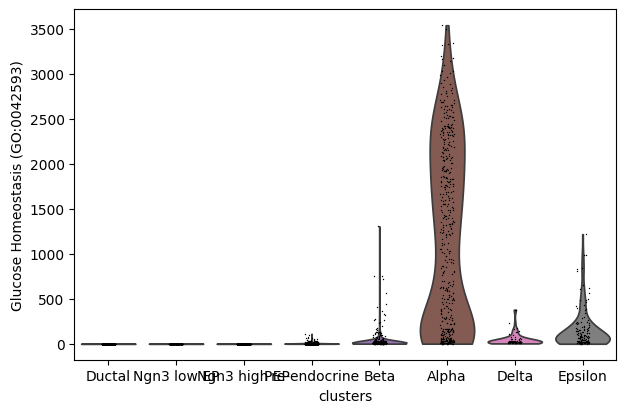

In [ ]:
# We plot the velocity of a gene program in the space of latent state
sc.pl.violin(adata_gp, keys='Glucose Homeostasis (GO:0042593)', layer='velocity', groupby='clusters')

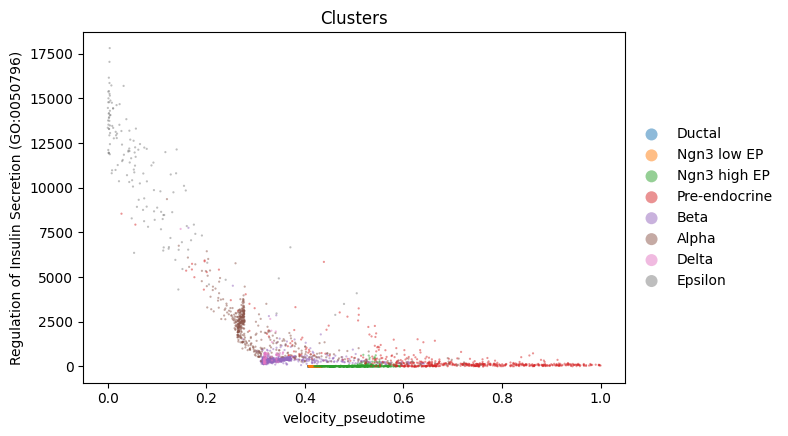

In [ ]:
# Plot the velocity of a gene program in the space of latent state
sc.pl.scatter(adata_gp, x='velocity_pseudotime', y='Regulation of Insulin Secretion (GO:0050796)', color='clusters', layers='velocity', size=10, alpha=0.5, title='Clusters')

In [ ]:
# Differential expression analysis via Wilcoxon rank-sum tests on expression,

# Differential expression (e.g. spliced layer)
de = vae.differential(adata, "clusters", layer="Ms")
adata.uns['diff_spliced'] = de

# Differential gene velocity
dvelo = vae.differential(adata, "clusters", layer="velocity")
adata.uns['diff_velo'] = dvelo

# Differential latent (gene program activations)
dlatent = vae.differential(adata, "clusters", obsm="mean")
adata.uns['diff_latent'] = dlatent

# Differential GP velocity
dgp = vae.differential(adata, "clusters", obsm="velocity_gp")
adata.uns['diff_gp_velo'] = dgp

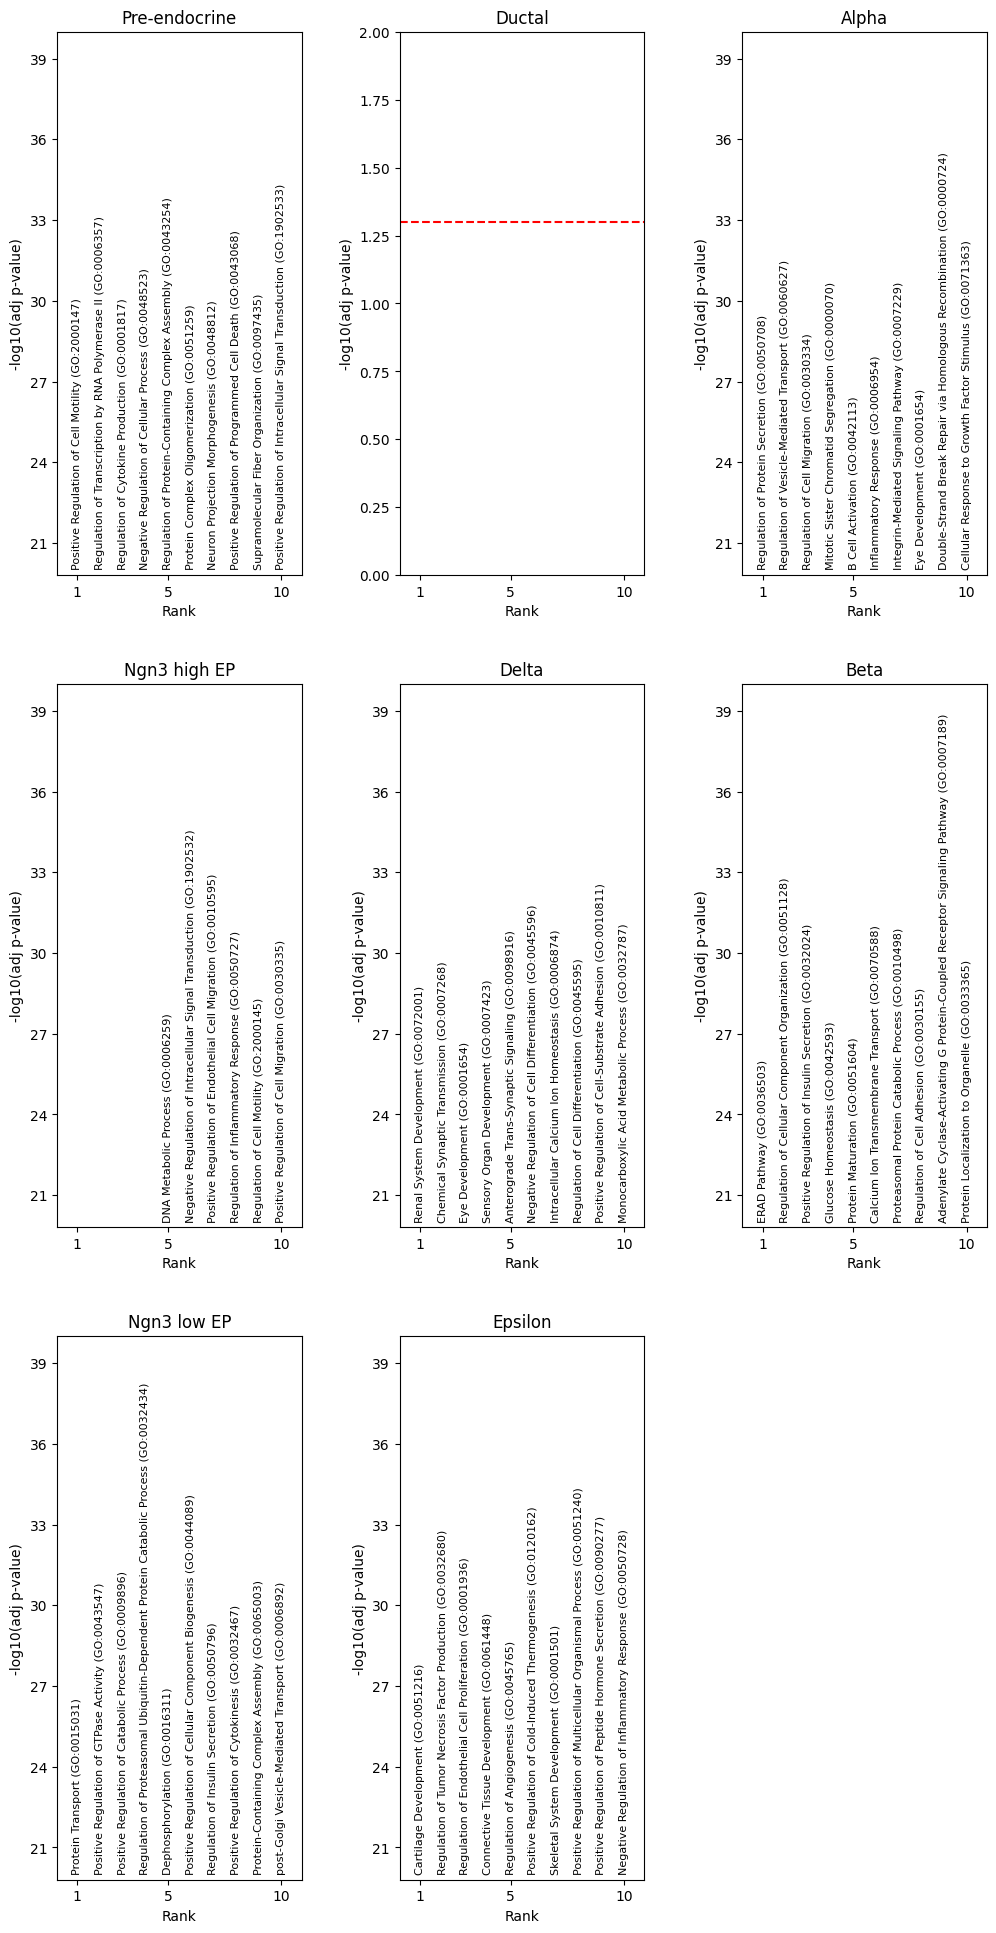

In [ ]:
# Plot results for the differential activation of a gene program
lineagevi.plots.plot_differential(adata, scores_key='diff_latent', n_points=10, lim_val=1.3)

In [ ]:
# Plot results for the differential velocity of a gene program
lineagevi.plots.plot_differential(adata, scores_key='diff_gp_velo', n_points=10, lim_val=1.3)

KeyboardInterrupt: 

In [ ]:
# Get a signature gene list, in this case, the gene programs with largest velocity across all lineages
df = lineagevi.plots.top_features_table(adata_gp, groupby_key="clusters", categories='all', layer="velocity", n=10)
list(df.feature)

In [ ]:
# Plot the heatmap a gene signature of choice, e.g. top velocity genes a
lineagevi.plots.heatmap(
    adata_gp,
    list(df.feature),
    sortby='velocity_pseudotime',
    layer='Ms',
    col_color='clusters',
    figsize=(10, 6),
)

In [ ]:
# Let's check which is the top velocity gene in Alpha cells, so we can perturb it
lineagevi.plots.top_features_table(adata, groupby_key="clusters", categories=['Alpha'], layer="velocity", n=10)

In [ ]:
# Let's perturb the gene for glucagon in pancreatic alpha cells (glucagon-producing cells)
df_genes, df_gps, perturbed_outputs = vae.perturb(
    adata,
    mode='genes',
    groupby_key='clusters',
    group_to_perturb='Alpha',
    genes_to_perturb=['Gcg'],
    perturb_value=0,
    perturb_spliced=True,
    perturb_unspliced=True,
)


In [ ]:
df_genes

In [ ]:
df_gps

In [ ]:
# Lets see which is the top velocity gene program in Alpha cells, so we can perturb it
lineagevi.plots.top_features_table(adata_gp, groupby_key="clusters", categories=['Beta'], layer="velocity", n=10)

In [ ]:
# Lets perturb the gene program for insulin secretion in pancreatic beta cells (insulin-producing cells)
df_genes_latent, df_gps_latent, out_latent = vae.perturb(
    adata,
    mode='gps',
    gp_uns_key='terms',
    gps_to_perturb=['Regulation of Insulin Secretion (GO:0050796)'],
    groupby_key='clusters',
    group_to_perturb='Beta',
    perturb_value=0,
)


In [ ]:
# Which gene velocities were perturbed the most from this perturbation?
df_genes_latent

In [ ]:
# Which GP velocities were perturbed the most from this perturbation?
df_gps_latent

In [ ]:
'''vae.intrinsic_uncertainty(
    adata,
    use_gp_velo = False,
    n_samples = 50,
    n_jobs = -1,
    show_plot =  True,
    base_seed = None,
)'''

In [ ]:
'''df = vae.compute_extrinsic_uncertainty(
    adata,
    use_gp_velo=True,
    n_samples=25, 
    n_jobs=-1,
    show_plot=True)
'''